# Детекция ботов-парсеров по событиям куки

Score от 0 до 1 для каждой куки, метрика: Precision при Recall >= 70%, считаем официальным `metric.py`.
Результат: 0.873 на скрытом тесте при 0.094 у константы, на CV по времени 0.86-0.88.

Подход:
1. Очистка: берем только события внутри окна, события после окна вместе с капчей дают утечку. Удаляем дубли, приводим `platform` к трем значениям.
2. 119 поведенческих признаков: паузы, курсор, листание выдачи, состав событий, возраст куки, тип клиента из UA.
3. Граф общих объявлений: боты одного сервиса ходят по общему списку. Берем только прошлые дни и текущий, без меток.
4. Второй уровень модели добавляет оценки соседей по графу, метка самой куки в них не попадает.
5. LightGBM + CatBoost, по 3 сида. Валидация по времени: учим на прошлых днях.

## 1. Данные
Код лежит в `src/`: очистка, признаки, граф, модели, валидация. `make_submission.py` собирает сабмит, долгие эксперименты кешируем в `artifacts/`.

In [1]:
import sys
import time
import warnings
from pathlib import Path

import catboost
import lightgbm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import xgboost
from IPython.display import display
from sklearn.metrics import roc_auc_score

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
DATA, ART = ROOT / "data", ROOT / "artifacts"

from data import clean_events, load_events, load_meta
from features import CATEGORICAL, feature_blocks, pointer_features, ua_family
from graph import coview_pairs, pair_features
from metric import precision_at_recall
from pipeline import (SEED, Blend, add_neighbor_features, build_dataset, make_catboost, make_final_model,
                      make_lgbm, make_xgb, stage1_scores, two_stage_fit_predict, two_stage_fit_predict_fn,
                      window_day)
from validation import bootstrap_ci, by_day_folds, cached, cross_validate, forward_folds, score_all

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 50, "display.width", 200, "display.max_colwidth", 120)
print(f"python {sys.version.split()[0]} | numpy {np.__version__} | pandas {pd.__version__} | "
      f"sklearn {sklearn.__version__} | lightgbm {lightgbm.__version__} | catboost {catboost.__version__} | "
      f"xgboost {xgboost.__version__}")

python 3.14.6 | numpy 2.5.3 | pandas 3.0.6 | sklearn 1.9.1 | lightgbm 4.7.0 | catboost 1.2.10 | xgboost 3.4.1


In [2]:
# цвета: люди синие, боты оранжевые, пара различима и при дальтонизме
C_HUMAN, C_BOT, INK, INK2, GRID = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#e1e0d9"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.spines.top": False,
    "axes.spines.right": False, "axes.titlesize": 11, "axes.titleweight": "bold", "font.size": 9,
    "legend.frameon": False,
})

In [3]:
meta = load_meta(DATA)
events = load_events(DATA)
train_mask = meta.part.eq("train").to_numpy()

print("куки:", meta.part.value_counts().to_dict(), "| событий:", len(events))
display(meta.groupby("part").agg(
    куки=("cookie_id", "size"),
    первый_день=("window_start_ts", "min"),
    последний_день=("window_start_ts", "max"),
    длина_окна_ч=("window_end_ts", lambda s: (s - meta.loc[s.index, "window_start_ts"]).dt.total_seconds().max() / 3600),
    доля_ботов=("target", "mean"),
))

куки: {'train': 11091, 'test': 4909} | событий: 328905


,куки,первый_день,последний_день,длина_окна_ч,доля_ботов
part,,,,,
test,4909,2026-04-20,2026-04-26,24.0,NaN
train,11091,2026-04-06,2026-04-19,24.0,0.081057


Train: 14 дней с 6 по 19 апреля, test: следующие 7 дней, ботов 8.1%. Тест идет после трейна, поэтому валидация по времени.

## 2. Проблемы в логе событий

### Утечка: события после окна

In [4]:
ev_w = events.merge(meta[["cookie_id", "window_start_ts", "window_end_ts", "part", "target"]], on="cookie_id")
ev_w["где"] = np.select([ev_w.event_ts < ev_w.window_start_ts, ev_w.event_ts >= ev_w.window_end_ts],
                        ["до окна", "после окна"], "в окне")
display(pd.crosstab(ev_w.part, ev_w["где"]))
display(pd.crosstab(ev_w.event_name, ev_w["где"]).loc[["captcha_shown", "item_view", "search_results_view"]])

after = ev_w[ev_w["где"].eq("после окна")]
captcha_after = meta.cookie_id.isin(after.loc[after.event_name.eq("captcha_shown"), "cookie_id"])
any_after = meta.cookie_id.isin(after.cookie_id)
print("доля ботов в train среди кук с капчей после окна:  ", round(meta.target[captcha_after & train_mask].mean(), 3))
print("доля ботов в train среди кук с событиями после окна:", round(meta.target[any_after & train_mask].mean(), 3),
      "| без них:", round(meta.target[~any_after & train_mask].mean(), 3))

где,в окне,после окна
part,,
test,89690,0
train,198436,40779


где,в окне,после окна
event_name,,
captcha_shown,0,7928
item_view,108086,12731
search_results_view,89798,10604


доля ботов в train среди кук с капчей после окна:   0.771
доля ботов в train среди кук с событиями после окна: 0.131 | без них: 0.036


В train ~41 тыс. событий после окна, в том числе вся капча: кука с капчей оказывается ботом в 77% случаев. В test таких событий нет. Берем только события внутри окна.

### Дубли, платформа, порядок, пропуски, UA

In [5]:
dup = events.duplicated()
ev_d = events.assign(дубль=dup).merge(meta[["cookie_id", "part", "target"]], on="cookie_id")
print(f"полных дубликатов: {dup.sum()} ({dup.mean():.2%})")
display(pd.concat({
    "по части": ev_d.groupby("part").дубль.mean(),
    "по классу (train)": ev_d.groupby("target").дубль.mean().rename(index={0.0: "человек", 1.0: "бот"}),
}).to_frame("доля дублей").T.round(4))
display(ev_d.groupby("event_name").дубль.mean().round(4).to_frame("доля дублей").T)

полных дубликатов: 4863 (1.48%)


по части         по классу (train)        
                test   train           человек     бот
доля дублей    0.015  0.0147            0.0148  0.0142

event_name,captcha_shown,contact_chat_open,contact_message_sent,contact_phone_show,favorite_add,item_view,login,photo_swipe,search_results_view,seller_page_view
доля дублей,0.0122,0.0127,0.0159,0.0143,0.0163,0.0151,0.0142,0.0152,0.0147,0.0128


1.5% строк - полные дубли, у всех классов поровну. Это шум логирования, удаляем.

In [6]:
display(events.platform.value_counts().to_frame().T)
norm = events.platform.str.lower().replace({"desktop": "web", "iphone": "ios"})
print("разных сырых значений на куку:", events.groupby("cookie_id").platform.nunique().value_counts().sort_index().to_dict())
print("после нормализации:           ", norm.groupby(events.cookie_id).nunique().value_counts().to_dict())

platform,desktop,WEB,Web,web,ANDROID,Android,android,iphone,IOS,iOS,ios
count,46866,46476,46365,45951,42462,42254,42159,4103,4100,4091,4078


разных сырых значений на куку: {1: 444, 2: 1312, 3: 7144, 4: 7100}


после нормализации:            {1: 16000}


11 написаний трех платформ. После нормализации у каждой куки одна платформа.

In [7]:
print("доля соседних строк одной и той же куки:", round((events.cookie_id == events.cookie_id.shift()).mean(), 4),
      "(строки идут вперемешку, нужна сортировка)")

na = events.drop(columns=["cookie_id", "event_ts", "eid", "event_name", "platform", "user_agent"]).isna()
display(na.groupby(events.event_name).mean().round(2).rename(columns=lambda c: c.replace("item_", "")))
ptr = events.pointer_x.notna().groupby([norm, events.cookie_id.map(meta.set_index("cookie_id").target)]).mean()
print("доля событий с координатами курсора, web: люди", round(ptr["web"][0.0], 2), "| боты", round(ptr["web"][1.0], 2),
      "| android/ios:", ptr.drop("web").max())

доля соседних строк одной и той же куки: 0.0001 (строки идут вперемешку, нужна сортировка)


,id,category,location,seller_type,search_query,search_page,pointer_x,pointer_y
event_name,,,,,,,,
captcha_shown,1.0,1.00,1.00,1.00,1.0,1.0,0.73,0.73
contact_chat_open,0.0,0.06,0.03,0.08,1.0,1.0,0.69,0.69
contact_message_sent,0.0,0.06,0.03,0.09,1.0,1.0,0.68,0.68
contact_phone_show,0.0,0.06,0.03,0.09,1.0,1.0,0.68,0.68
favorite_add,0.0,0.06,0.03,0.09,1.0,1.0,0.65,0.65
item_view,0.0,0.06,0.03,0.09,1.0,1.0,0.67,0.67
login,1.0,1.00,1.00,1.00,1.0,1.0,0.65,0.65
photo_swipe,0.0,0.06,0.03,0.09,1.0,1.0,0.66,0.66
search_results_view,1.0,0.06,0.03,1.00,0.0,0.0,0.67,0.67


доля событий с координатами курсора, web: люди 0.66 | боты 0.36 | android/ios: 0.0


Строки идут вперемешку, сортируем по времени. Курсор есть только на web, у ботов вдвое реже, поэтому пропуск сам несет сигнал. Остальные пропуски структурные или случайные.

In [8]:
ua_tab = (events.drop_duplicates("cookie_id").merge(meta[["cookie_id", "target", "part"]], on="cookie_id")
          .assign(семейство=lambda d: d.user_agent.map(ua_family)))
print("уникальных строк User-Agent:", events.user_agent.nunique())
display(ua_tab[ua_tab.part.eq("train")].groupby("семейство").agg(кук=("target", "size"), доля_ботов=("target", "mean"))
        .sort_values("доля_ботов", ascending=False).round(3).T)

уникальных строк User-Agent: 148


семейство,headless,http_lib,app,desktop_chrome,firefox,yabrowser,mobile_safari,mobile_chrome
кук,286.000,200.00,2141.000,2780.00,1423.000,1228.000,192.000,2841.000
доля_ботов,0.262,0.22,0.092,0.09,0.084,0.081,0.047,0.037


148 уникальных UA. Сырую строку не берем: на версиях и моделях устройств модель переобучается. Оставляем тип клиента, сигнал у него слабый.

In [9]:
ev = clean_events(events, meta)
ev.head(3)

событий в файле:           328,905
  дубликатов:                4,863
  до начала окна:                0
  после конца окна:         40,209  (утечка, отбрасываем)
событий в окнах:           283,833


,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y,t
0,ck_00013fdfa0bd37dd,2026-04-24 18:41:16,210,photo_swipe,android,"Mozilla/5.0 (Linux; Android 12; Pixel 6) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0.0 Mobile Safari/537.36",1012349.0,rabota,moskva,private,NaN,NaN,NaN,NaN,67276.0
1,ck_00013fdfa0bd37dd,2026-04-24 19:16:53,200,item_view,android,"Mozilla/5.0 (Linux; Android 12; Pixel 6) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0.0 Mobile Safari/537.36",1054355.0,rabota,moskva,private,NaN,NaN,NaN,NaN,69413.0
2,ck_00013fdfa0bd37dd,2026-04-24 19:16:54,210,photo_swipe,android,"Mozilla/5.0 (Linux; Android 12; Pixel 6) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0.0 Mobile Safari/537.36",1015683.0,detskie_tovary,habarovsk,pro,NaN,NaN,NaN,NaN,69414.0


## 3. Чем боты отличаются от людей

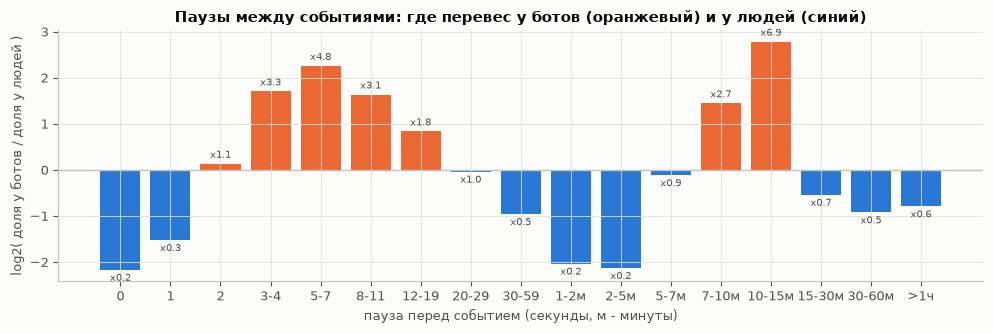

In [10]:
evt = ev.merge(meta[["cookie_id", "target"]], on="cookie_id")
evt = evt[evt.target.notna()]
evt["gap"] = evt.t.diff().where(evt.cookie_id.eq(evt.cookie_id.shift()))

edges = [0, 1, 2, 3, 5, 8, 12, 20, 30, 60, 120, 300, 450, 600, 900, 1800, 3600, 86400]
labels = ["0", "1", "2", "3-4", "5-7", "8-11", "12-19", "20-29", "30-59", "1-2м", "2-5м", "5-7м", "7-10м",
          "10-15м", "15-30м", "30-60м", ">1ч"]
b = pd.cut(evt.gap, edges, right=False, labels=labels)
share = pd.crosstab(b, evt.target, normalize="columns")
lr = np.log2(share[1.0] / share[0.0])

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(range(len(lr)), lr.values, color=[C_BOT if v > 0 else C_HUMAN for v in lr.values], width=0.8)
ax.axhline(0, color="#c3c2b7", lw=1)
ax.set_xticks(range(len(lr)), lr.index, rotation=0)
ax.set_xlabel("пауза перед событием (секунды, м - минуты)")
ax.set_ylabel("log2( доля у ботов / доля у людей )")
ax.set_title("Паузы между событиями: где перевес у ботов (оранжевый) и у людей (синий)")
for i, v in enumerate(lr.values):
    ax.text(i, v + (0.08 if v > 0 else -0.08), f"x{2 ** v:.1f}", ha="center", va="bottom" if v > 0 else "top",
            fontsize=7, color=INK2)
plt.tight_layout()
plt.show()

Паузы 3-12 с и 7-15 мин чаще у ботов, паузы от 30 с до 5 мин чаще у людей.

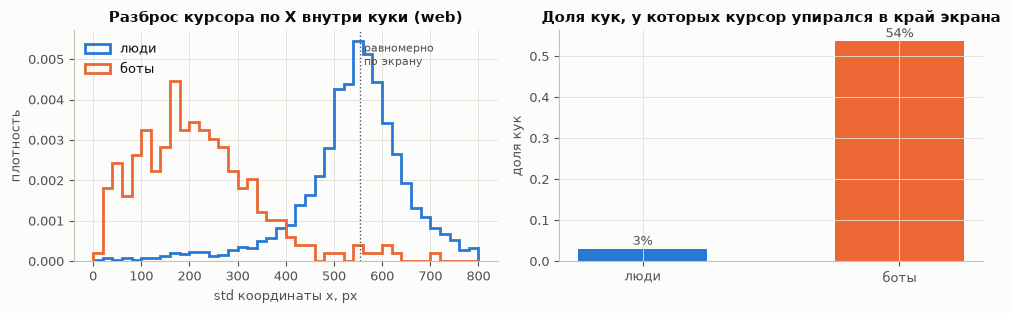

In [11]:
pf = pointer_features(ev).join(meta.set_index("cookie_id").target)
pf = pf[pf.target.notna() & (pf.pointer_n >= 3)]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
bins = np.linspace(0, 800, 41)
for t, c, name in [(0, C_HUMAN, "люди"), (1, C_BOT, "боты")]:
    axes[0].hist(pf.loc[pf.target == t, "pointer_x_std"], bins=bins, density=True, histtype="step", lw=2, color=c, label=name)
axes[0].axvline(1920 / np.sqrt(12), color=INK2, ls=":", lw=1)
axes[0].text(1920 / np.sqrt(12) + 8, axes[0].get_ylim()[1] * 0.85, "равномерно\nпо экрану", fontsize=8, color=INK2)
axes[0].set_title("Разброс курсора по X внутри куки (web)")
axes[0].set_xlabel("std координаты x, px"); axes[0].set_ylabel("плотность"); axes[0].legend()

edge = pf.groupby("target").pointer_edge_share.apply(lambda s: (s > 0).mean())
axes[1].bar(["люди", "боты"], edge.values, color=[C_HUMAN, C_BOT], width=0.5)
for i, v in enumerate(edge.values):
    axes[1].text(i, v + 0.01, f"{v:.0%}", ha="center", color=INK2)
axes[1].set_title("Доля кук, у которых курсор упирался в край экрана")
axes[1].set_ylabel("доля кук")
plt.tight_layout()
plt.show()

У людей курсор равномерно покрывает экран, у ботов собран у одной точки и чаще упирается в край.

### Боты ходят по общим спискам объявлений

In [12]:
views = ev.loc[ev.item_id.notna(), ["cookie_id", "item_id"]].drop_duplicates().merge(meta[["cookie_id", "target"]], on="cookie_id")
views = views[views.target.notna()]
n_bot, n_hum = (views.target == 1).sum(), (views.target == 0).sum()
print(f"боты:  {n_bot} просмотров -> {views[views.target == 1].item_id.nunique()} разных объявлений "
      f"(при равномерном выборе из 60 тыс. было бы {60000 * (1 - np.exp(-n_bot / 60000)):.0f})")
print(f"люди:  {n_hum} просмотров -> {views[views.target == 0].item_id.nunique()} разных объявлений "
      f"(при равномерном выборе было бы {60000 * (1 - np.exp(-n_hum / 60000)):.0f})")
bot_day = views[views.target == 1].cookie_id.map(meta.set_index("cookie_id").window_start_ts)
week1 = set(views[views.target == 1].item_id[bot_day < "2026-04-13"])
week2 = set(views[views.target == 1].item_id[bot_day >= "2026-04-13"])
print(f"объявлений ботов 2-й недели, которые боты открывали и на 1-й: {len(week1 & week2) / len(week2):.0%}")

pairs = coview_pairs(ev, meta)
max_shared = pairs.groupby("cookie_id").n_shared.max().reindex(meta.cookie_id).fillna(0).to_numpy()
tab = (pd.DataFrame({"общих объявлений с самым похожим соседом": np.clip(max_shared[train_mask], 0, 5).astype(int),
                     "target": meta.target[train_mask]})
       .groupby("общих объявлений с самым похожим соседом").target.agg(кук="size", доля_ботов="mean"))
tab.index = tab.index.map(lambda k: "5+" if k == 5 else str(k))
display(tab.round(3).T)

боты:  12388 просмотров -> 6957 разных объявлений (при равномерном выборе из 60 тыс. было бы 11193)
люди:  90884 просмотров -> 45538 разных объявлений (при равномерном выборе было бы 46808)
объявлений ботов 2-й недели, которые боты открывали и на 1-й: 44%


общих объявлений с самым похожим соседом,0,1,2,3,4,5+
кук,1416.000,8540.00,848.00,122.000,68.000,97.000
доля_ботов,0.029,0.05,0.23,0.705,0.868,0.948


Люди выбирают объявления равномерно, боты берут их из узкого списка своего сервиса. Если у куки 3+ общих объявления с другой кукой за неделю, это бот в 70-95% случаев. Признаки графа берем только по прошлым дням и текущему, без меток других кук. Второй уровень добавляет оценки соседей, метка самой куки в них не попадает.

## 4. Признаки
119 поведенческих признаков: паузы и сессии, время чтения, курсор, листание, состав событий, возраст куки, тип клиента. Еще 2 графовых. Нет событий - 0. Если у доли нулевой знаменатель - NaN, бустинг обработает его сам. Категориальные признаки имеют тип `category`.

In [13]:
meta, X, pairs = build_dataset(DATA, verbose=False)
blocks = {name: list(df.columns) for name, df in feature_blocks(ev, meta).items()}
blocks["граф: общие объявления"] = list(pair_features(pairs, meta.cookie_id).columns)
print(f"признаки: {X.shape[1]} на {X.shape[0]} кук")
display(pd.Series({k: len(v) for k, v in blocks.items()}, name="признаков").to_frame().T)

y_all, day_all = meta.target.to_numpy(), window_day(meta)
X_tr, y_tr = X[train_mask], y_all[train_mask].astype(int)

признаки: 121 на 16000 кук


,возраст куки,объем и состав событий,"объявления, категории, города",поиск и листание выдачи,"паузы, сессии, время суток",время чтения страниц,переходы между событиями,курсор,user agent и платформа,граф: общие объявления
признаков,3,24,12,10,40,9,7,9,5,2


## 5. Валидация
Основная схема forward: учим только на прошлых днях, 4 фолда по 2 дня. Вспомогательная by_day: 7 фолдов по 2 дня. Метрика из официального `metric.py`.

In [14]:
day_tr = pd.Series(day_all[train_mask])
FOLDS = {"forward": forward_folds(day_tr), "by_day": by_day_folds(day_tr)}
dates = meta.window_start_ts[train_mask].dt.strftime("%d.%m").to_numpy()
for name, folds in FOLDS.items():
    print(name)
    for tr, va in folds:
        excl = sorted(set(dates[va]))
        src = f"обучение {dates[tr].min()}-{dates[tr].max()}" if name == "forward" else "обучение на остальных днях"
        print(f"   {src:28s} ({len(tr):5d} кук) -> валидация {', '.join(excl)} ({len(va)} кук, ботов {y_tr[va].sum()})")

forward
   обучение 06.04-11.04         ( 5113 кук) -> валидация 12.04, 13.04 (1660 кук, ботов 120)
   обучение 06.04-13.04         ( 6773 кук) -> валидация 14.04, 15.04 (1627 кук, ботов 135)
   обучение 06.04-15.04         ( 8400 кук) -> валидация 16.04, 17.04 (1453 кук, ботов 126)
   обучение 06.04-17.04         ( 9853 кук) -> валидация 18.04, 19.04 (1238 кук, ботов 94)
by_day
   обучение на остальных днях   ( 9522 кук) -> валидация 06.04, 07.04 (1569 кук, ботов 127)
   обучение на остальных днях   ( 9355 кук) -> валидация 08.04, 09.04 (1736 кук, ботов 136)
   обучение на остальных днях   ( 9283 кук) -> валидация 10.04, 11.04 (1808 кук, ботов 161)
   обучение на остальных днях   ( 9431 кук) -> валидация 12.04, 13.04 (1660 кук, ботов 120)
   обучение на остальных днях   ( 9464 кук) -> валидация 14.04, 15.04 (1627 кук, ботов 135)
   обучение на остальных днях   ( 9638 кук) -> валидация 16.04, 17.04 (1453 кук, ботов 126)
   обучение на остальных днях   ( 9853 кук) -> валидация 18.04, 19

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

graph_cols = blocks["граф: общие объявления"]
behavior_cols = [c for c in X.columns if c not in graph_cols]

def adversarial_auc(features: pd.DataFrame, is_second: np.ndarray) -> float:
    # Может ли модель отличить одну группу кук от другой? 0.5 - группы неразличимы
    clf = make_lgbm(n_estimators=300, learning_rate=0.05, num_leaves=15, min_child_samples=50,
                    scale_pos_weight=1.0, colsample_bytree=1.0)
    cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
    p = cross_val_predict(clf, features, is_second.astype(int), cv=cv, method="predict_proba")[:, 1]
    return roc_auc_score(is_second, p)

late = day_all >= 7   # 13-19 апреля
full_hist = day_all >= 6  # дни, для которых есть полная неделя истории
checks = {
    "поведение: train vs test": adversarial_auc(X[behavior_cols], ~train_mask),
    "поведение: train 6-12 vs 13-19 апр.": adversarial_auc(X.loc[train_mask, behavior_cols], late[train_mask]),
    "поведение, только боты: 6-12 vs 13-19": adversarial_auc(X.loc[train_mask & (y_all == 1), behavior_cols], late[train_mask & (y_all == 1)]),
    "поведение, только люди: 6-12 vs 13-19": adversarial_auc(X.loc[train_mask & (y_all == 0), behavior_cols], late[train_mask & (y_all == 0)]),
    "граф (пары кук): train с полной историей vs test": adversarial_auc(X.loc[full_hist, graph_cols], ~train_mask[full_hist]),
}
pd.Series(checks, name="adversarial ROC-AUC").round(3).to_frame()

,adversarial ROC-AUC
поведение: train vs test,0.508
поведение: train 6-12 vs 13-19 апр.,0.490
"поведение, только боты: 6-12 vs 13-19",0.510
"поведение, только люди: 6-12 vs 13-19",0.492
граф (пары кук): train с полной историей vs test,0.513


Дрейфа нет, AUC около 0.5, обе схемы подходят.

## 6. От baseline к финальной модели

In [16]:
RESULTS = []

def evaluate(name: str, fit_predict, X_train: pd.DataFrame, key: str) -> dict:
    # CV по обеим схемам, результат кешируем в artifacts/cv_<схема>_<key>.pkl
    row, out = {"эксперимент": name}, {}
    for scheme, folds in FOLDS.items():
        res = cached(ART / f"cv_{scheme}_{key}.pkl",
                     lambda: cross_validate(fit_predict, X_train, y_tr, folds, name))
        out[scheme] = res
        row[f"{scheme}: P@R среднее фолдов"] = res.fold_scores["P@R0.7"].mean()
        row[f"{scheme}: P@R все OOF"] = res.pooled["P@R0.7"]
        row[f"{scheme}: PR-AUC"] = res.pooled["PR-AUC"]
    RESULTS.append(row)
    display(pd.DataFrame([row]).set_index("эксперимент").round(3))
    return out

def fit_predict_with(make_model, cols=None):
    def fit_predict(X_fit, y_fit, X_pred):
        if cols is not None:
            X_fit, X_pred = X_fit[cols], X_pred[cols]
        return make_model().fit(X_fit, y_fit).predict_proba(X_pred)[:, 1]
    return fit_predict

# 0) Константа: у всех кук одинаковый score, precision равен доле ботов
const = precision_at_recall(y_tr, np.zeros(len(y_tr)))
RESULTS.append({"эксперимент": "константа", **{f"{s}: {m}": const for s in FOLDS for m in ["P@R среднее фолдов", "P@R все OOF", "PR-AUC"]}})
print("константа:", round(const, 3))

константа: 0.081


In [17]:
# 1) Baseline из quickstart: RandomForest на двух агрегатах, события окна без дедупликации
from sklearn.ensemble import RandomForestClassifier

raw_in = ev_w[ev_w["где"].eq("в окне")]
qs = (raw_in.groupby("cookie_id").agg(n_events=("event_ts", "size"), item_nunique=("item_id", "nunique"))
      .reindex(meta.cookie_id).fillna(0))
evaluate("baseline quickstart: RF(n_events, item_nunique)",
         fit_predict_with(lambda: RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0, n_jobs=-1)),
         qs[train_mask], "baseline_rf");

,forward: P@R среднее фолдов,forward: P@R все OOF,forward: PR-AUC,by_day: P@R среднее фолдов,by_day: P@R все OOF,by_day: PR-AUC
эксперимент,,,,,,
"baseline quickstart: RF(n_events, item_nunique)",0.101,0.101,0.216,0.108,0.108,0.217


In [18]:
# 2) Логистическая регрессия на всех поведенческих признаках
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def make_logreg():
    num = [c for c in behavior_cols if c not in CATEGORICAL]
    prep = ColumnTransformer([
        ("num", make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler()), num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
    ])
    return make_pipeline(prep, LogisticRegression(C=0.1, max_iter=5000))

evaluate("логрегрессия: поведенческие признаки", fit_predict_with(make_logreg, behavior_cols), X_tr, "logreg");

,forward: P@R среднее фолдов,forward: P@R все OOF,forward: PR-AUC,by_day: P@R среднее фолдов,by_day: P@R все OOF,by_day: PR-AUC
эксперимент,,,,,,
логрегрессия: поведенческие признаки,0.667,0.669,0.747,0.714,0.703,0.762


In [19]:
# 3-5) LightGBM: сначала исходные параметры, потом параметры из поиска, см. раздел 7
INITIAL = dict(n_estimators=500, learning_rate=0.03, num_leaves=15, min_child_samples=30, subsample=0.8,
               subsample_freq=1, colsample_bytree=0.7, reg_lambda=1.0, reg_alpha=0.0, scale_pos_weight=1.0)
make_initial = lambda: make_lgbm(**INITIAL)

evaluate("LightGBM: поведенческие признаки", fit_predict_with(make_initial, behavior_cols), X_tr, "lgbm_behavior")
evaluate("  + граф: пары кук с общими объявлениями", fit_predict_with(make_initial), X_tr, "lgbm_graph")
evaluate("  + подобранные параметры LightGBM", fit_predict_with(make_lgbm), X_tr, "lgbm_tuned");

,forward: P@R среднее фолдов,forward: P@R все OOF,forward: PR-AUC,by_day: P@R среднее фолдов,by_day: P@R все OOF,by_day: PR-AUC
эксперимент,,,,,,
LightGBM: поведенческие признаки,0.775,0.77,0.795,0.805,0.792,0.807


,forward: P@R среднее фолдов,forward: P@R все OOF,forward: PR-AUC,by_day: P@R среднее фолдов,by_day: P@R все OOF,by_day: PR-AUC
эксперимент,,,,,,
+ граф: пары кук с общими объявлениями,0.84,0.839,0.818,0.839,0.838,0.82


,forward: P@R среднее фолдов,forward: P@R все OOF,forward: PR-AUC,by_day: P@R среднее фолдов,by_day: P@R все OOF,by_day: PR-AUC
эксперимент,,,,,,
+ подобранные параметры LightGBM,0.839,0.847,0.821,0.85,0.848,0.821


In [20]:
# 6) Второй уровень: оценки соседей по графу от модели первого уровня, без утечки меток.
#    LightGBM усредняем по 3 сидам, так сравнение меньше шумит.
lgbm_bag = lambda: Blend([make_lgbm])
two_stage_cv = evaluate("  + 2-й уровень: оценки соседей (LightGBM, 3 сида)",
                        two_stage_fit_predict_fn(X, y_all, day_all, pairs, lgbm_bag), X_tr, "two_stage_lgbm3")

# Финальная модель: та же схема с ансамблем LightGBM + CatBoost, см. раздел 7.
# CV ансамбля во второй ступени здесь не запускаем, оценку схемы берем из строки выше.
# Включить: RUN_BLEND_CV = True.
RUN_BLEND_CV = False
if RUN_BLEND_CV:
    evaluate("  + ансамбль LightGBM + CatBoost (финал)",
             two_stage_fit_predict_fn(X, y_all, day_all, pairs, make_final_model), X_tr, "two_stage_blend")

,forward: P@R среднее фолдов,forward: P@R все OOF,forward: PR-AUC,by_day: P@R среднее фолдов,by_day: P@R все OOF,by_day: PR-AUC
эксперимент,,,,,,
"+ 2-й уровень: оценки соседей (LightGBM, 3 сида)",0.882,0.879,0.83,0.863,0.867,0.826


In [21]:
summary = pd.DataFrame(RESULTS).set_index("эксперимент")
summary.round(3)

,forward: P@R среднее фолдов,forward: P@R все OOF,forward: PR-AUC,by_day: P@R среднее фолдов,by_day: P@R все OOF,by_day: PR-AUC
эксперимент,,,,,,
константа,0.081,0.081,0.081,0.081,0.081,0.081
"baseline quickstart: RF(n_events, item_nunique)",0.101,0.101,0.216,0.108,0.108,0.217
логрегрессия: поведенческие признаки,0.667,0.669,0.747,0.714,0.703,0.762
LightGBM: поведенческие признаки,0.775,0.770,0.795,0.805,0.792,0.807
+ граф: пары кук с общими объявлениями,0.840,0.839,0.818,0.839,0.838,0.820
+ подобранные параметры LightGBM,0.839,0.847,0.821,0.850,0.848,0.821
"+ 2-й уровень: оценки соседей (LightGBM, 3 сида)",0.882,0.879,0.830,0.863,0.867,0.826


Главные приросты: бустинг на поведенческих признаках поднимает P@R с 0.10 до 0.78-0.80, граф добавляет 0.03-0.07, второй уровень доводит до 0.88 и 0.86.

### Шум метрики

In [22]:
for scheme, res in two_stage_cv.items():
    ok = ~np.isnan(res.oof)
    lo, hi = bootstrap_ci(y_tr[ok], res.oof[ok], n_boot=500, seed=SEED)
    print(f"{scheme:8s} P@R по всем OOF = {res.pooled['P@R0.7']:.3f}, 95% ДИ [{lo:.3f}, {hi:.3f}] | по фолдам:",
          res.fold_scores["P@R0.7"].round(3).tolist())

forward  P@R по всем OOF = 0.879, 95% ДИ [0.829, 0.923] | по фолдам: [0.884, 0.95, 0.873, 0.819]


by_day   P@R по всем OOF = 0.867, 95% ДИ [0.831, 0.896] | по фолдам: [0.795, 0.882, 0.832, 0.923, 0.911, 0.882, 0.819]


Шум около 0.03, разницу меньше я не считаю значимой.

### Что не взял
* сырая строка UA, версии браузера и ОС, модели устройств: модель переобучается, прироста нет;
* плотность общих просмотров и максимум по всем соседям: сдвиг между train и test, прироста нет;
* модель уровня событий; XGBoost, его прогноз меняется от числа потоков.

## 7. Модели

In [23]:
from sklearn.metrics import log_loss

def random_search(n_configs=40, seed=42):
    rng = np.random.default_rng(seed)
    configs = [dict(INITIAL, learning_rate=0.02)]
    for _ in range(n_configs):
        configs.append(dict(
            learning_rate=0.02, subsample_freq=1,
            n_estimators=int(rng.choice([300, 450, 600, 800])), num_leaves=int(rng.choice([7, 15, 31, 63])),
            max_depth=int(rng.choice([-1, 4, 6, 8])), min_child_samples=int(rng.choice([10, 20, 40, 80, 150])),
            colsample_bytree=float(rng.choice([0.3, 0.5, 0.7, 0.9])), subsample=float(rng.choice([0.6, 0.8, 1.0])),
            reg_lambda=float(rng.choice([0, 1, 5, 20])), reg_alpha=float(rng.choice([0, 0.1, 1])),
            min_split_gain=float(rng.choice([0, 0.01, 0.1])), scale_pos_weight=float(rng.choice([1, 1, 2, 4]))))
    rows = []
    for params in configs:
        row = dict(params)
        for s, f in FOLDS.items():
            r = cross_validate(fit_predict_with(lambda: make_lgbm(**params)), X_tr, y_tr, f)
            ok = ~np.isnan(r.oof)
            row[f"{s}: P@R среднее"] = r.fold_scores["P@R0.7"].mean()
            row[f"{s}: P@R OOF"] = r.pooled["P@R0.7"]
            row[f"{s}: PR-AUC"] = r.pooled["PR-AUC"]
            row[f"{s}: logloss"] = log_loss(y_tr[ok], r.oof[ok])
        rows.append(row)
    return pd.DataFrame(rows)

search = cached(ART / "lgbm_random_search.pkl", random_search)
metric_cols = [c for c in search.columns if ":" in c]
search["балл P@R"] = search[[c for c in metric_cols if "P@R" in c]].mean(axis=1)
search["PR-AUC"] = search[[c for c in metric_cols if "PR-AUC" in c]].mean(axis=1)
search["logloss"] = search[[c for c in metric_cols if "logloss" in c]].mean(axis=1)
search["средний ранг"] = (search["балл P@R"].rank(ascending=False) + search["PR-AUC"].rank(ascending=False)
                          + search["logloss"].rank()) / 3
show = ["n_estimators", "num_leaves", "max_depth", "min_child_samples", "colsample_bytree", "subsample",
        "reg_lambda", "reg_alpha", "scale_pos_weight", "балл P@R", "PR-AUC", "logloss", "средний ранг"]
print("исходная конфигурация (строка 0):", search.loc[0, ["балл P@R", "PR-AUC", "logloss"]].round(4).to_dict())
search.sort_values("средний ранг")[show].head(8).round(4)

исходная конфигурация (строка 0): {'балл P@R': 0.8347, 'PR-AUC': 0.8218, 'logloss': 0.1113}


,n_estimators,num_leaves,max_depth,min_child_samples,colsample_bytree,subsample,reg_lambda,reg_alpha,scale_pos_weight,балл P@R,PR-AUC,logloss,средний ранг
24,450,63,-1.0,80,0.5,1.0,5.0,0.1,2.0,0.8463,0.8209,0.1108,2.6667
32,600,31,-1.0,20,0.3,0.8,5.0,1.0,4.0,0.8517,0.8205,0.1122,5.0000
0,500,15,NaN,30,0.7,0.8,1.0,0.0,1.0,0.8347,0.8218,0.1113,7.3333
3,600,15,-1.0,150,0.9,0.8,1.0,1.0,1.0,0.8433,0.8193,0.1120,8.0000
2,600,63,6.0,80,0.7,1.0,5.0,0.0,1.0,0.8366,0.8202,0.1116,9.3333
29,450,15,6.0,40,0.5,1.0,0.0,0.1,1.0,0.8339,0.8204,0.1114,10.0000
12,450,63,6.0,40,0.7,0.8,0.0,0.0,1.0,0.8385,0.8210,0.1132,10.3333
31,450,63,-1.0,150,0.7,0.6,1.0,0.1,1.0,0.8405,0.8189,0.1122,11.3333


Берем конфигурацию с лучшим средним рангом по P@R, PR-AUC и logloss.

Бустинги и их ансамбли, первый уровень:

In [24]:
MAKERS = {"LightGBM": make_lgbm, "XGBoost": make_xgb, "CatBoost": make_catboost}

def model_oof(name, seed):
    return {s: cached(ART / f"cv_{s}_stage1_{name}_seed{seed}.pkl",
                      lambda: cross_validate(fit_predict_with(lambda: MAKERS[name](SEED + seed)), X_tr, y_tr, f)).oof
            for s, f in FOLDS.items()}

N_SEEDS = 1
oofs = {(m, k): model_oof(m, k) for m in MAKERS for k in range(N_SEEDS)}

def blend_scores(models):
    row = {}
    for s, f in FOLDS.items():
        p = np.mean([oofs[(m, k)][s] for m in models for k in range(N_SEEDS)], axis=0)
        ok = ~np.isnan(p)
        row[f"{s}: P@R среднее фолдов"] = np.mean([precision_at_recall(y_tr[va], p[va]) for _, va in f])
        row[f"{s}: P@R все OOF"] = precision_at_recall(y_tr[ok], p[ok])
        row[f"{s}: PR-AUC"] = score_all(y_tr[ok], p[ok])["PR-AUC"]
    return row

combos = [["LightGBM"], ["XGBoost"], ["CatBoost"], ["LightGBM", "XGBoost"], ["LightGBM", "CatBoost"],
          ["XGBoost", "CatBoost"], ["LightGBM", "XGBoost", "CatBoost"]]
models_tab = pd.DataFrame({" + ".join(c): blend_scores(c) for c in combos}).T
models_tab["среднее 4 P@R"] = models_tab[[c for c in models_tab.columns if "P@R" in c]].mean(axis=1)
models_tab.round(4)

,forward: P@R среднее фолдов,forward: P@R все OOF,forward: PR-AUC,by_day: P@R среднее фолдов,by_day: P@R все OOF,by_day: PR-AUC,среднее 4 P@R
LightGBM,0.8394,0.8473,0.8210,0.8504,0.8479,0.8208,0.8463
XGBoost,0.8289,0.8524,0.8211,0.8403,0.8504,0.8205,0.8430
CatBoost,0.8428,0.8375,0.8229,0.8454,0.8583,0.8240,0.8460
LightGBM + XGBoost,0.8474,0.8586,0.8229,0.8436,0.8531,0.8224,0.8507
LightGBM + CatBoost,0.8480,0.8564,0.8273,0.8574,0.8550,0.8267,0.8542
XGBoost + CatBoost,0.8660,0.8564,0.8279,0.8591,0.8608,0.8269,0.8606
LightGBM + XGBoost + CatBoost,0.8541,0.8593,0.8272,0.8559,0.8618,0.8265,0.8578


In [25]:
# Воспроизводимость: меняется ли прогноз от числа потоков?
X_fit, X_pred = X_tr, X[~train_mask]
for name, make, key in [("LightGBM", make_lgbm, "n_jobs"), ("XGBoost", make_xgb, "n_jobs"), ("CatBoost", make_catboost, "thread_count")]:
    p1 = make(**{key: 1}).fit(X_fit, y_tr).predict_proba(X_pred)[:, 1]
    p8 = make(**{key: 8}).fit(X_fit, y_tr).predict_proba(X_pred)[:, 1]
    print(f"{name:9s} max |p(1 поток) - p(8 потоков)| = {np.abs(p1 - p8).max():.2e}")

LightGBM  max |p(1 поток) - p(8 потоков)| = 0.00e+00


XGBoost   max |p(1 поток) - p(8 потоков)| = 1.55e-01


CatBoost  max |p(1 поток) - p(8 потоков)| = 0.00e+00


Финал: LightGBM + CatBoost по 3 сида. Качество не хуже, результат воспроизводится.

## 8. Сабмит

In [26]:
# Тот же вызов, что в make_submission.py. Если submission.csv уже есть,
# ноутбук его не пересчитывает, а загружает и проверяет.
sub_path = ROOT / "submission.csv"
if not sub_path.exists():
    train_pos, test_pos = np.flatnonzero(train_mask), np.flatnonzero(~train_mask)
    score = two_stage_fit_predict(X, y_all, day_all, pairs, train_pos, test_pos, make_final_model)
    pd.DataFrame({"cookie_id": meta.cookie_id.iloc[test_pos].to_numpy(), "score": score}).to_csv(sub_path, index=False)

submission = pd.read_csv(sub_path)
score = submission.score.to_numpy()
test_ids = pd.read_csv(DATA / "test.csv", usecols=["cookie_id"]).cookie_id
assert len(submission) == len(test_ids) and set(submission.cookie_id) == set(test_ids)
assert submission.cookie_id.is_unique and submission.score.notna().all() and submission.score.between(0, 1).all()
print("submission.csv:", submission.shape, "| уникальных score:", submission.score.nunique())
submission.head()

submission.csv: (4909, 2) | уникальных score: 4909


,cookie_id,score
0,ck_315fb710a0e371e7,0.001241
1,ck_a76ee3b3e3e522fd,0.027205
2,ck_94c9a4d382689e82,0.025850
3,ck_8eaf9509ad9462a0,0.000339
4,ck_9a88a5a989cb5bc6,0.008366
